In [126]:
import pandas as pd
import numpy as np

In [127]:
train = pd.read_csv('train.csv')

In [128]:
train.head().T

,0,1,2,3,4
PassengerId,1,2,3,4,5
Survived,0,1,1,1,0
Pclass,3,1,3,1,3
Name,"Braund, Mr. Owen Harris","Cumings, Mrs. John Bradley (Florence Briggs Th...","Heikkinen, Miss. Laina","Futrelle, Mrs. Jacques Heath (Lily May Peel)","Allen, Mr. William Henry"
Sex,male,female,female,female,male
Age,22.0,38.0,26.0,35.0,35.0
SibSp,1,1,0,1,0
Parch,0,0,0,0,0
Ticket,A/5 21171,PC 17599,STON/O2. 3101282,113803,373450
Fare,7.25,71.2833,7.925,53.1,8.05


In [129]:
train.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)

In [130]:
train.head().T

,0,1,2,3,4
Survived,0,1,1,1,0
Pclass,3,1,3,1,3
Sex,male,female,female,female,male
Age,22.0,38.0,26.0,35.0,35.0
SibSp,1,1,0,1,0
Parch,0,0,0,0,0
Fare,7.25,71.2833,7.925,53.1,8.05
Cabin,NaN,C85,NaN,C123,NaN
Embarked,S,C,S,S,S


In [131]:
dtypes = train.dtypes
n_unique = train.nunique()
pd.DataFrame({'Dtypes': dtypes, 'num_unique': n_unique}).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Dtypes,int64,int64,object,float64,int64,int64,float64,object,object
num_unique,2,3,2,88,7,7,248,147,3


In [132]:
from check_dtype import check_dtype
check_dtype(train)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Dtypes,int64,int64,object,float64,int64,int64,float64,object,object
num_unique,2,3,2,88,7,7,248,147,3


In [133]:
check_dtype(train)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Dtypes,int64,int64,object,float64,int64,int64,float64,object,object
num_unique,2,3,2,88,7,7,248,147,3


In [134]:
cols = ['Survived', 'Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked']
train[cols] = train[cols].astype('category')

In [135]:
from handle_types import handle_types
handle_types(train, cols)

In [136]:
nulls = train.isnull().sum()
ratio = nulls / train.shape[0]
pd.DataFrame({'nulls': nulls, 'ratio': ratio}).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
nulls,0.0,0.0,0.0,177.000000,0.0,0.0,0.0,687.000000,2.000000
ratio,0.0,0.0,0.0,0.198653,0.0,0.0,0.0,0.771044,0.002245


In [137]:
train.dropna(subset=['Embarked'], inplace=True)

In [138]:
train = train.drop(columns=['Cabin'],axis=1)

In [139]:
median = train['Age'].median()
train['Age'].fillna(median, inplace=True)

C:\Users\NOTEBOOK\AppData\Local\Temp\ipykernel_8720\3923942648.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['Age'].fillna(median, inplace=True)


In [140]:
nulls = train.isnull().sum()
ratio = nulls / train.shape[0]
pd.DataFrame({'nulls': nulls, 'ratio': ratio}).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
nulls,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ratio,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [141]:
import matplotlib.pyplot as plt
import seaborn as sns

In [142]:
train.dtypes

Survived    category
Pclass      category
Sex         category
Age          float64
SibSp       category
Parch       category
Fare         float64
Embarked    category
dtype: object

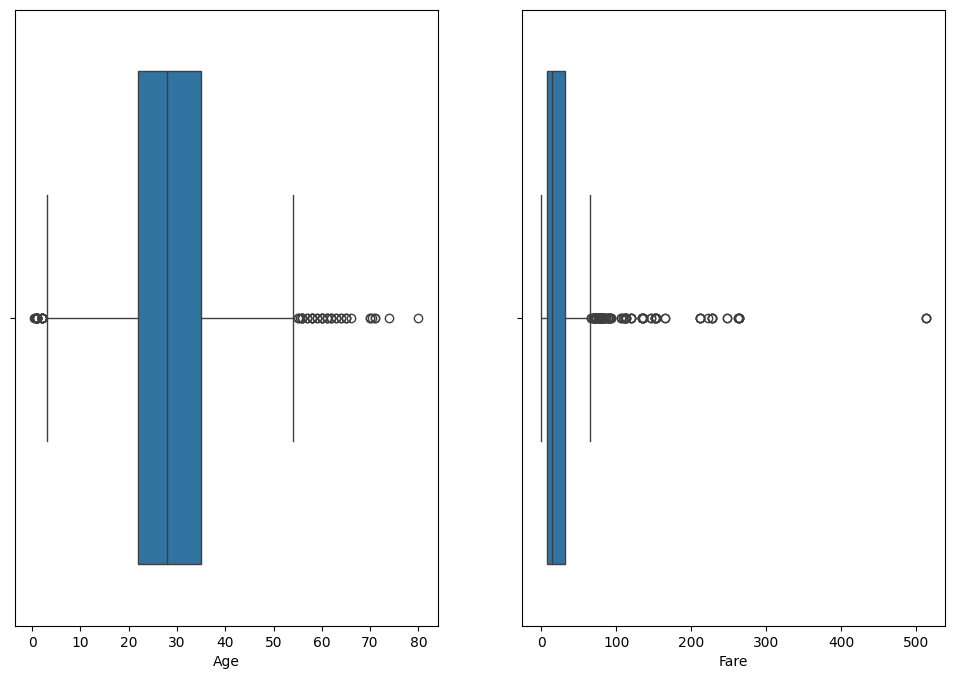

In [143]:
num_cols = train.select_dtypes('number').columns
plt.figure(figsize=(12,8))
for i, col in enumerate(num_cols):
    plt.subplot(1, 2, i+1)
    sns.boxplot(train[col], orient='h')

In [144]:
for col in num_cols:
    q1 = train[col].quantile(0.25)
    q3 = train[col].quantile(0.75)
    iqr = q3 - q1
    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr
    lower_outlier = train[train[col] < lower_fence]
    upper_outlier = train[train[col] > upper_fence]

    train.loc[train[col] < lower_fence, col] = lower_fence
    train.loc[train[col] > upper_fence, col] = upper_fence

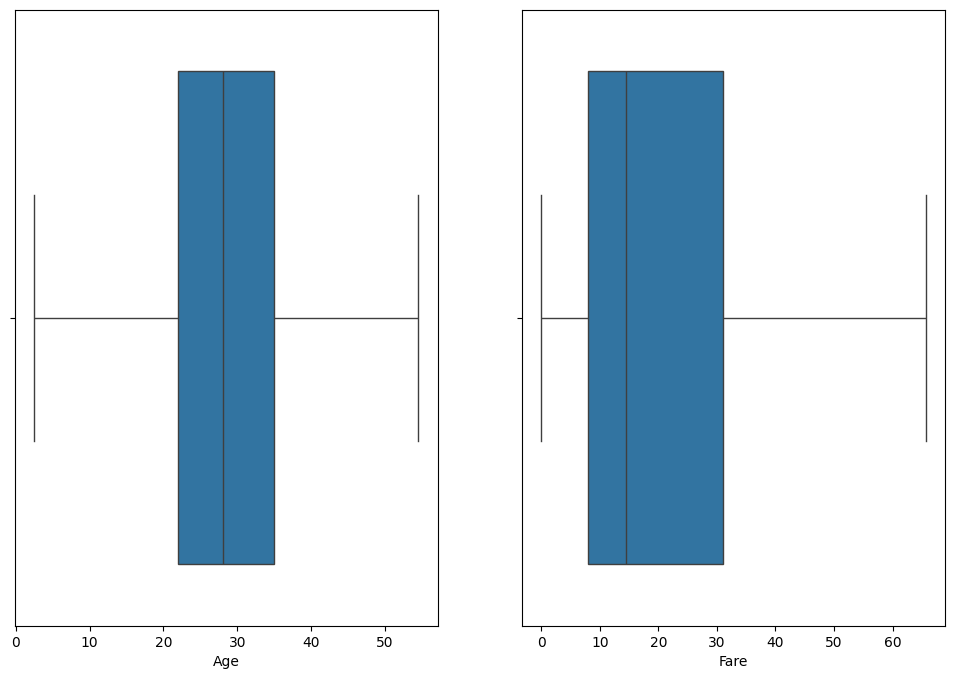

In [145]:
num_cols = train.select_dtypes('number').columns
plt.figure(figsize=(12,8))
for i, col in enumerate(num_cols):
    plt.subplot(1, 2, i+1)
    sns.boxplot(train[col], orient='h')

In [146]:
train.duplicated().sum()

np.int64(129)

In [147]:
train.drop_duplicates(inplace=True)
train.duplicated().sum()

np.int64(0)

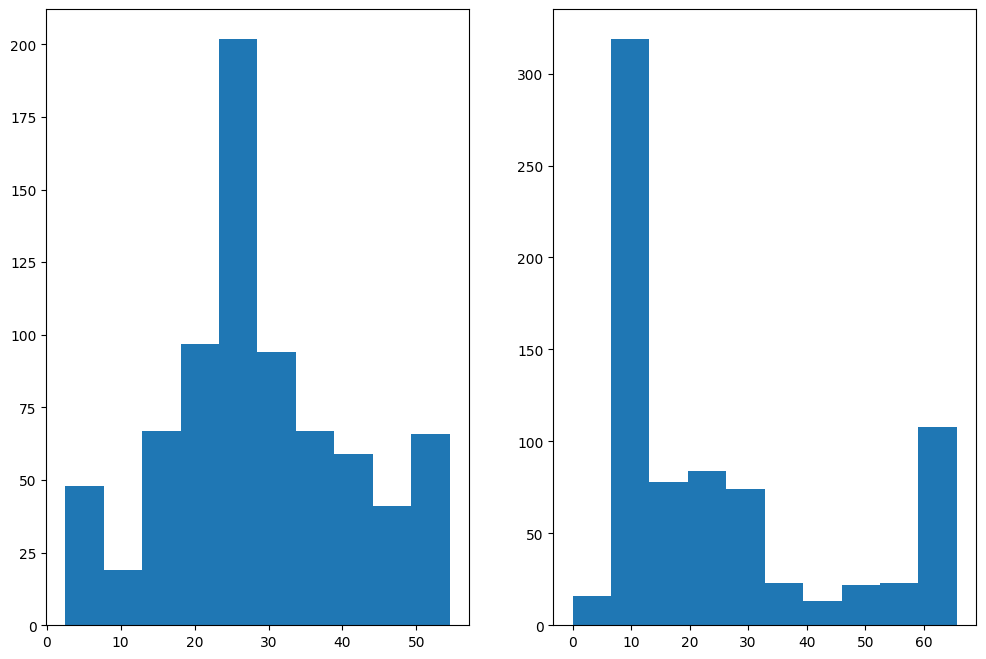

In [148]:
num_cols = train.select_dtypes('number').columns
plt.figure(figsize=(12,8))
for i, col in enumerate(num_cols):
    plt.subplot(1, 2, i+1)
    plt.hist(train[col])
plt.show()

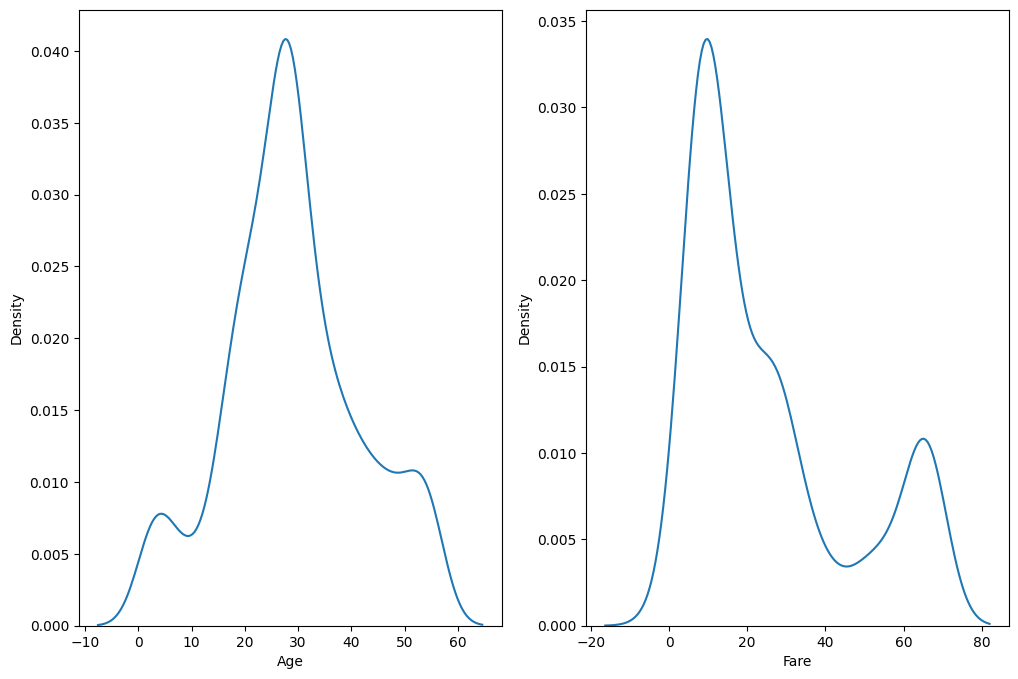

In [149]:
num_cols = train.select_dtypes('number').columns
plt.figure(figsize=(12,8))
for i, col in enumerate(num_cols):
    plt.subplot(1, 2, i+1)
    sns.kdeplot(train[col])
plt.show()

In [150]:
cat_cols = train.select_dtypes('category').columns
cat_cols

Index(['Survived', 'Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked'], dtype='object')

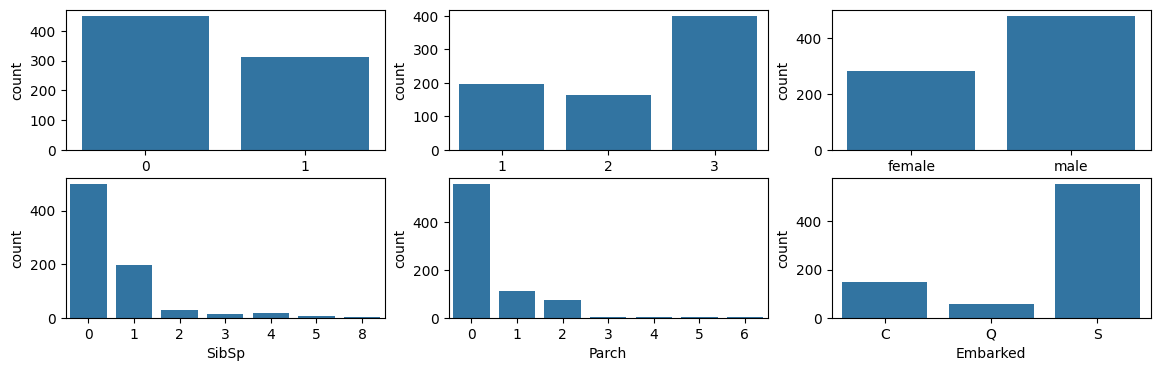

In [152]:
cat_cols = train.select_dtypes('category').columns
plt.figure(figsize=(14,4))
for i, col in enumerate(cat_cols):
    plt.subplot(2, 3, i+1)
    sns.countplot(x = col, data = train)
plt.show()